# Deep Reinforcement Learning Class Spring 2026 Assignment 3 Q1

This is the first part of the assignment. In this part, you will learn DQN and its variants with the AcroBot environment from OpenAI Gym.

You need to fill in the missing code snippets (marked by TODO). Feel free to modify the code structure based on your understanding, but **you are forbidden to use any external RL libraries like Stable Baselines3**, **RLlib**, etc.

Make a copy of this notebook using File > Save a copy in Drive and edit it with your answers.

WARNING: Do not put your name or any other personal identification information in this notebook.

## Question 1-1: Random Agent (5%)

We will start by loading AcroBot environment and creating a random agent.

First, install the required packages and import the necessary libraries.

In [ ]:
!pip install gymnasium
!pip install imageio

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "2"

In [2]:
import os
import random
from collections import deque

import math
import gymnasium as gym
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.optim.lr_scheduler import ExponentialLR
import matplotlib.pyplot as plt
from IPython.display import Image, display
import imageio

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


---
### Understanding the AcroBot Environment

The Acrobot is a two-link underactuated robot, analogous to a gymnast swinging on a high bar. The system consists of two rigid links connected by actuated joints, with the first link fixed to a pivot point. The control objective is to swing the endpoint of the second link above a specified height.

#### State Space

The observation is a 6-dimensional continuous vector:

| Index | Variable | Description | Range |
|-------|----------|-------------|-------|
| 0 | $\cos(\theta_1)$ | Cosine of angle of link 1 | $[-1, 1]$ |
| 1 | $\sin(\theta_1)$ | Sine of angle of link 1 | $[-1, 1]$ |
| 2 | $\cos(\theta_2)$ | Cosine of angle of link 2 | $[-1, 1]$ |
| 3 | $\sin(\theta_2)$ | Sine of angle of link 2 | $[-1, 1]$ |
| 4 | $\dot{\theta}_1$ | Angular velocity of link 1 | $[-4\pi, 4\pi]$ |
| 5 | $\dot{\theta}_2$ | Angular velocity of link 2 | $[-9\pi, 9\pi]$ |

#### Action Space

The agent can apply one of three discrete torques to the joint between the two links:

| Action | Torque |
|--------|--------|
| 0 | $-1$ (negative torque) |
| 1 | $0$ (no torque) |
| 2 | $+1$ (positive torque) |

#### Reward Structure

- The agent receives a reward of $-1$ for each timestep until termination
- Episode terminates when the tip reaches the target height, or after 500 steps (truncation)

More information about this environment can be found [here](https://gymnasium.farama.org/environments/classic_control/acrobot/)

In [3]:
env = gym.make("Acrobot-v1", render_mode="rgb_array")

print("Environment Specifications:")
print(f"  Observation space: {env.observation_space}")
print(f"  Action space: {env.action_space}")
print(f"  Max episode steps: {env.spec.max_episode_steps}")

obs, info = env.reset(seed=42)
print(f"\nSample observation: {obs}")
print(f"Observation dtype: {obs.dtype}")

Environment Specifications:
  Observation space: Box([ -1.        -1.        -1.        -1.       -12.566371 -28.274334], [ 1.        1.        1.        1.       12.566371 28.274334], (6,), float32)
  Action space: Discrete(3)
  Max episode steps: 500

Sample observation: [ 0.99849933  0.0547638   0.99992526 -0.01222401  0.07171959  0.0394736 ]
Observation dtype: float32


### Implementing the Random Agent (5%)

We will implement a random agent that selects actions randomly from the action space of the environment. Random agents are useful for testing the environment and ensuring that it is working as expected.

ALSA lib confmisc.c:855:(parse_card) [error.core] cannot find card '0'
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) [error.core] error evaluating strings
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) [error.core] error evaluating name
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5730:(snd_config_expand) [error.core] Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) [error.pcm] Unknown PCM default


Total reward: -500.0


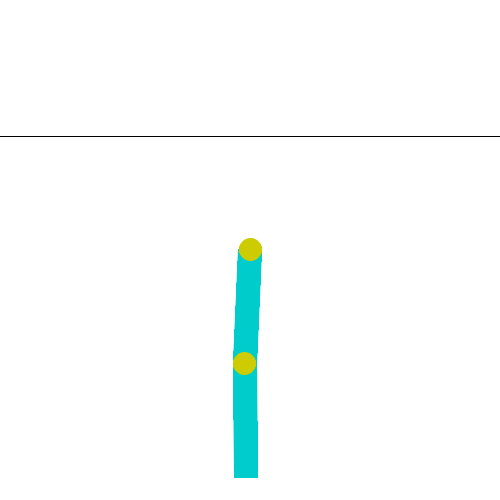

In [4]:
frames = [] # Store the frames for the animation

observation, _ = env.reset()
done = False
total_reward = 0
while not done:
    # TODO: Select an action randomly
    action = env.action_space.sample()

    # TODO: Take a step in the environment
    # observation, reward, terminated, truncated, info = ...
    observation, reward, terminated, truncated, info = env.step(action)

    # TODO: Check if the episode is done
    done = terminated or truncated

    # TODO: Update the total reward
    total_reward += reward

    frames.append(env.render()) # Save the frame for the animation

env.close()
print("Total reward:", total_reward)

# Visulization
### Do not modify the follwing code—any changes will result in a score of 0 for this question.
gif_path = "random_agent.gif"
imageio.mimsave(gif_path, frames, fps=30)
display(Image(filename=gif_path))

---
## Question 1-2: DQN Agent (10%)

Next, we will implement a Deep Q-Networks (DQN) agent that learns to play the AcroBot-v1 game. DQN is a reinforcement learning algorithm that uses a deep neural network to approximate the Q-function, allowing the agent to estimate the expected future rewards for each action and learn an optimal policy.

In this question, we will:

1. Define a neural network model to approximate the Q-function.
2. Implement the experience replay buffer to store past experiences.
3. Implement the DQN agent that interacts with the environment, updates the network, and learns to play the game.

By completing this section, you will build the core components of a DQN-based reinforcement learning agent that can successfully land the spacecraft in the AcroBot-v1 environment! 🚀

### Defining the Neural Network Model

In [5]:
class QNetwork(nn.Module):
    """
    Q-Network implemented as a multi-layer perceptron.

    Args:
        obs_dim: Dimension of observation space
        action_dim: Number of discrete actions
        hidden_dim: Number of hidden units per layer
    """

    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 64):
        super().__init__()
        # TODO: Define the network architecture
        self.network = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, action_dim)
        )


    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Compute Q-values for all actions.

        Args:
            x: State tensor of shape (batch_size, obs_dim)

        Returns:
            Q-values of shape (batch_size, action_dim)
        """
        return self.network(x)

### Implementing the Experiment Replay Buffer

In [6]:
class ReplayBuffer:
    """
    Fixed-size circular buffer for storing experience tuples.

    Stores transitions (s, a, r, s', done) and supports uniform random sampling.

    Args:
        capacity: Maximum number of transitions to store
    """

    # TODO: Initialize the buffer data structure
    def __init__(self, capacity: int):
        self.buffer = deque(maxlen=capacity)

    # TODO: Implement the push method
    def push(self, state, action, reward, next_state, done):
        """Add a transition to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    # TODO: Implement the sample method
    def sample(self, batch_size: int):
        """Sample a batch of transitions uniformly at random."""
        transitions = random.sample(self.buffer, batch_size)

        states, actions, rewards, next_states, dones = zip(*transitions)

        states = torch.FloatTensor(np.array(states)).to(device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(device)
        next_states = torch.FloatTensor(np.array(next_states)).to(device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(device)

        return states, actions, rewards, next_states, dones

    def __len__(self):
        return len(self.buffer)

### Defining the DQN Agent

In [7]:
class DQNAgent:
    """
    Deep Q-Network agent.

    Implements the DQN algorithm with experience replay and target network.

    Args:
        config: Dictionary containing hyperparameters
    """

    def __init__(self):
        # TODO: Initialize some parameters, networks, optimizer, and replay buffer
        self.batch_size = 128
        self.gamma = 0.99
        self.lr = 5e-4

        obs_dim = 6
        action_dim = 3

        self.policy_net = QNetwork(obs_dim, action_dim).to(device)
        self.target_net = QNetwork(obs_dim, action_dim).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.scheduler = ExponentialLR(self.optimizer, gamma=0.995)
        self.loss_fn = nn.SmoothL1Loss()

        self.memory = ReplayBuffer(10000)

    def select_action(self, state: np.ndarray, epsilon: float) -> int:
        """
        Select action using epsilon-greedy policy.

        With probability epsilon, select a random action.
        Otherwise, select the action with highest Q-value.

        Args:
            state: Current state observation
            epsilon: Exploration probability

        Returns:
            Selected action (integer in [0, action_dim))
        """
        # TODO: Implement epsilon-greedy action selection
        if random.random() < epsilon:
            return random.randrange(3)
        else:
            with torch.no_grad():
                state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
                q_values = self.policy_net(state_tensor)
                return q_values.argmax().item()


    def train(self):
        """
        Perform one gradient update step.

        Samples a batch from replay buffer and updates the policy network
        using the DQN loss.
        """
        if len(self.memory) < self.batch_size:
            return  # Not enough samples to train

        # TODO: Sample a batch from replay buffer and update the policy network
        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # Compute current Q-values
        current_q_values = self.policy_net(states).gather(1, actions)

        # Compute TD target
        with torch.no_grad():
            next_q_values = self.target_net(next_states).max(1)[0].unsqueeze(1)
            expected_q_values = rewards + (self.gamma * next_q_values * (1 - dones))

        # TODO: Compute loss and update the model
        loss = self.loss_fn(current_q_values, expected_q_values)

        # TODO: Update target network periodically
        self.optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

    def update_target_network(self, tau=0.005):
        """Soft update policy network weights to target network."""
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

### Setting up the Training Loop

In [8]:
def train_dqn(seed: int = 42):
    """
    Train a DQN agent.

    Args:
        seed: Random seed for reproducibility

    Returns:
        Tuple of (trained_agent, evaluation_history)
    """
    # Set random seeds
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    # Initialize environment and agent
    env = gym.make("Acrobot-v1")
    agent = DQNAgent()

    # Training metrics
    reward_history = []

    # TODO: Determine the number of episodes for training
    num_episodes = 400

    epsilon_start = 1.0
    epsilon_end = 0.002
    epsilon_decay = 0.985

    epsilon = epsilon_start

    for episode in range(1, num_episodes + 1):
        # TODO: Reset environment
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0
        done = False

        # Episode loop
        while not done:
            # TODO: select an action from the agent
            action = agent.select_action(state, epsilon)
            # TODO: Add the experience to the replay buffer and train the agent
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            agent.memory.push(state, action, reward, next_state, terminated)
            agent.train()

            # Soft update
            agent.update_target_network(tau=0.005)

            # TODO: Update the state and total reward
            state = next_state
            episode_reward += reward

        # Decay epsilon
        epsilon = max(epsilon_end, epsilon * epsilon_decay)

        # Decay learning rate
        agent.scheduler.step()

        reward_history.append(episode_reward)

        # Print training progress every 20 episodes
        if episode % 20 == 0:
            avg_reward = np.mean(reward_history[-20:])
            print(f"Episode {episode:4d} | Reward: {episode_reward:6.1f} | Avg Reward (last 20): {avg_reward:6.1f} | Epsilon: {epsilon:.3f}")

    env.close()
    return agent, reward_history

In [ ]:
# Train the agent (requires completing the TODO sections above)
# You may modify the seed value
agent, reward_history = train_dqn(seed=42)

In [ ]:
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("Training History")
plt.show()

### Testing your DQN agent (15%)

Test your DQN agent for 10 episodes and calculate the average reward.

You will get full points if the average reward is greater than -100.

**Do not modify the cell below, or you will get zero points for this question.**

In [ ]:
def evaluate_policy(env, policy_fn, n_episodes=10, seed=42, filename="DQN_evaluation.gif", fps=30):
    """Evaluate a policy over multiple episodes."""
    rewards = []
    lengths = []
    frames = []

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep if seed else None)
        state = obs.flatten()
        total_reward = 0
        steps = 0
        done = False

        while not done:
            frames.append(env.render())
            action = policy_fn(state)
            obs, reward, terminated, truncated, _ = env.step(action)
            state = obs.flatten()
            total_reward += reward
            steps += 1
            done = terminated or truncated

        print(f'Reward: {total_reward}')
        rewards.append(total_reward)
        lengths.append(steps)

    imageio.mimsave(filename, frames, fps=fps)

    print(f'Average reward: {np.mean(rewards)}\nMean episode length: {np.mean(lengths)}')

    return filename

env_render = gym.make("Acrobot-v1", render_mode="rgb_array")
trained_policy = lambda state: agent.select_action(state, epsilon=0.0)
gif_filename = evaluate_policy(env_render, trained_policy)
env_render.close()
display(Image(filename=gif_filename))

## Question 1-3: Improving the DQN Agent (15%)

In this question, you need to improve the DQN agent by implementing one or more of the following DQN variants:

1. Double DQN
2. Dueling DQN
3. Prioritized Experience Replay
4. Deep Recurrent Q-Network
5. Rainbow DQN

After training, plot the reward history curve and compare the performance of your improved DQN agent with the original DQN implementation.  

Next, test your improved DQN agent for 10 episodes and compute the average reward over these trials.  

You will receive 10 points only if both of the following conditions are met:

- The average reward is greater than -75
- The average reward is higher than your original DQN agent


This final evaluation will help you assess whether your modifications have effectively improved the agent's performance. 🚀

### Noisy Nets

In [18]:
class NoisyLinear(nn.Module):
    def __init__(self, in_features, out_features, std_init=0.5):
        super(NoisyLinear, self).__init__()
        self.in_features = in_features
        self.out_features = out_features
        self.std_init = std_init
        
        # 可訓練的參數 (mu 和 sigma)
        self.weight_mu = nn.Parameter(torch.empty(out_features, in_features))
        self.weight_sigma = nn.Parameter(torch.empty(out_features, in_features))
        # 將 bias 註冊為 Parameter
        self.bias_mu = nn.Parameter(torch.empty(out_features))
        self.bias_sigma = nn.Parameter(torch.empty(out_features))
        
        # 不需要計算梯度的雜訊 (epsilon)
        # 使用 register_buffer 讓它們隨模型保存，但不會被 Optimizer 更新
        self.register_buffer('weight_epsilon', torch.empty(out_features, in_features))
        self.register_buffer('bias_epsilon', torch.empty(out_features))
        
        self.reset_parameters()
        self.reset_noise()
        
    def reset_parameters(self):
        # 根據 Factorized Noisy Nets 論文的建議進行權重初始化
        mu_range = 1 / math.sqrt(self.in_features)
        self.weight_mu.data.uniform_(-mu_range, mu_range)
        self.weight_sigma.data.fill_(self.std_init / math.sqrt(self.in_features))
        
        self.bias_mu.data.uniform_(-mu_range, mu_range)
        self.bias_sigma.data.fill_(self.std_init / math.sqrt(self.out_features))
        
    def _scale_noise(self, size):
        # 分解高斯雜訊的特殊函數 f(x) = sgn(x) * sqrt(|x|)
        x = torch.randn(size, device=self.weight_mu.device)
        return x.sign().mul_(x.abs().sqrt_())
        
    def reset_noise(self):
        # 每次呼叫這個函數時，重新生成雜訊
        epsilon_in = self._scale_noise(self.in_features)
        epsilon_out = self._scale_noise(self.out_features)
        
        # Outer product 產生權重矩陣的雜訊
        self.weight_epsilon.copy_(epsilon_out.ger(epsilon_in))
        self.bias_epsilon.copy_(epsilon_out)
        
    def forward(self, x):
        # 訓練模式下加上雜訊，評估模式 (eval) 下不加雜訊 (只用 mu)
        if self.training:
            weight = self.weight_mu + self.weight_sigma * self.weight_epsilon
            bias = self.bias_mu + self.bias_sigma * self.bias_epsilon
        else:
            weight = self.weight_mu
            bias = self.bias_mu
            
        return F.linear(x, weight, bias)

### Dueling

In [19]:
class DuelingNoisyQNetwork(nn.Module):
    def __init__(self, obs_dim: int, action_dim: int, hidden_dim: int = 64):
        super().__init__()
        
        # 共用的特徵提取層 (這裡保持一般的 Linear 即可)
        self.feature_layer = nn.Sequential(
            nn.Linear(obs_dim, hidden_dim),
            nn.ReLU()
        )
        
        # Value Stream: 輸出維度為 1 (V(s))
        # 將後面的層替換為 NoisyLinear
        self.value_stream = nn.Sequential(
            NoisyLinear(hidden_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, 1)
        )
        
        # Advantage Stream: 輸出維度為 action_dim (A(s, a))
        self.advantage_stream = nn.Sequential(
            NoisyLinear(hidden_dim, hidden_dim),
            nn.ReLU(),
            NoisyLinear(hidden_dim, action_dim)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        features = self.feature_layer(x)
        
        values = self.value_stream(features)
        advantages = self.advantage_stream(features)
        
        # 聚合公式: Q(s,a) = V(s) + A(s,a) - mean(A(s,a'))
        # 使用 keepdim=True 以確保可以正確 broadcast 減法
        q_values = values + (advantages - advantages.mean(dim=1, keepdim=True))
        
        return q_values
        
    def reset_noise(self):
        # 遞迴重置所有 NoisyLinear 層的雜訊
        for module in self.modules():
            if isinstance(module, NoisyLinear):
                module.reset_noise()

### Multi-step Learning

In [20]:
class NStepReplayBuffer:
    """
    N-step experience replay buffer.
    
    Internally maintains a small N-step deque to accumulate rewards,
    then stores the compressed (s_t, a_t, n_step_return, s_{t+n}, done) tuple.
    """

    def __init__(self, capacity: int, n_step: int = 3, gamma: float = 0.99):
        self.buffer = deque(maxlen=capacity)
        self.n_step = n_step
        self.gamma = gamma
        # 暫存最近 N 步，還沒折現完的 transitions
        self.n_step_buffer = deque(maxlen=n_step)

    def push(self, state, action, reward, next_state, done):
        """
        把一筆 transition 加進 n_step_buffer，
        如果 n_step_buffer 滿了，就計算 n-step return 並存入主 buffer。
        """
        self.n_step_buffer.append((state, action, reward, next_state, done))

        # 還沒累積夠 N 步，先等
        if len(self.n_step_buffer) < self.n_step:
            return

        # 從最舊的那筆 (s_t, a_t) 開始，往後折現 N 步
        R = 0.0
        for i, (_, _, r, _, d) in enumerate(self.n_step_buffer):
            R += (self.gamma ** i) * r
            if d:  # 如果中途 episode 結束，就截斷
                break

        # s_t, a_t 是最舊那筆；s_{t+n}, done_{t+n} 是最新那筆
        s_t, a_t, _, _, _ = self.n_step_buffer[0]
        _, _, _, s_tn, done_tn = self.n_step_buffer[-1]

        self.buffer.append((s_t, a_t, R, s_tn, done_tn))

    def flush(self):
        """
        Episode 結束時，把 n_step_buffer 裡剩餘的不完整序列也存進去。
        這樣 episode 結尾的經驗才不會被白白丟棄。
        """
        while len(self.n_step_buffer) > 0:
            R = 0.0
            for i, (_, _, r, _, d) in enumerate(self.n_step_buffer):
                R += (self.gamma ** i) * r
                if d:
                    break
            s_t, a_t, _, _, _ = self.n_step_buffer[0]
            _, _, _, s_tn, done_tn = self.n_step_buffer[-1]
            self.buffer.append((s_t, a_t, R, s_tn, done_tn))
            self.n_step_buffer.popleft()

    def sample(self, batch_size: int):
        """和原本一樣，均勻抽樣。"""
        transitions = random.sample(self.buffer, batch_size)
        states, actions, rewards, next_states, dones = zip(*transitions)

        return (
            torch.FloatTensor(np.array(states)).to(device),
            torch.LongTensor(actions).unsqueeze(1).to(device),
            torch.FloatTensor(rewards).unsqueeze(1).to(device),
            torch.FloatTensor(np.array(next_states)).to(device),
            torch.FloatTensor(dones).unsqueeze(1).to(device),
        )

    def __len__(self):
        return len(self.buffer)

### DQNVariant

In [21]:
# TODO: Implement your own DQN variant here, you may also need to create other classes
class DQNVariant:
    """
    結合 Dueling Architecture 與 Noisy Nets 的 DQN 變體
    """
    def __init__(self):
        self.batch_size = 128
        self.gamma = 0.99
        self.n_step = 3
        self.lr = 5e-4

        obs_dim = 6
        action_dim = 3

        # 替換為我們自定義的 Dueling + Noisy 網路
        self.policy_net = DuelingNoisyQNetwork(obs_dim, action_dim).to(device)
        self.target_net = DuelingNoisyQNetwork(obs_dim, action_dim).to(device)

        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=self.lr)
        self.scheduler = ExponentialLR(self.optimizer, gamma=0.995)
        self.loss_fn = nn.SmoothL1Loss()

        # self.memory = ReplayBuffer(10000)
        self.memory = NStepReplayBuffer(capacity=50000, n_step=self.n_step, gamma=self.gamma)

    def select_action(self, state: np.ndarray, epsilon: float = 1.0) -> int:
        """
        利用 Noisy Nets 的特性進行動作選擇。
        
        Args:
            state: 當前狀態
            epsilon: 這裡不再代表隨機機率。我們利用它作為一個 Flag：
                     如果 epsilon == 0.0 (作業測試階段)，則關閉雜訊，使用網路的平均權重(mu)。
                     如果 epsilon > 0.0 (訓練階段)，則開啟雜訊進行探索。
        """
        with torch.no_grad():
            state_tensor = torch.FloatTensor(state).unsqueeze(0).to(device)
            
            if epsilon == 0.0:
                self.policy_net.eval()  # 測試階段：關閉雜訊 (不加上 epsilon * sigma)
            else:
                self.policy_net.train() # 訓練階段：開啟雜訊進行探索
                
            q_values = self.policy_net(state_tensor)
            return q_values.argmax().item()

    def train(self):
        if len(self.memory) < self.batch_size:
            return  # 樣本數不足時不訓練

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        
        # 【關鍵步驟】計算 Loss 前，必須重置兩個網路的雜訊，確保每次前向傳播的隨機性都不同
        self.policy_net.reset_noise()
        self.target_net.reset_noise()
        
        # 計算當前的 Q 值
        current_q = self.policy_net(states).gather(1, actions)

        # 計算 TD Target
        with torch.no_grad():
            # Double DQN：
            # Step 1 - 用 policy_net 選出下一狀態的最佳動作
            next_actions = self.policy_net(next_states).argmax(1, keepdim=True)
            
            # Step 2 - 用 target_net 評估那個動作的 Q 值（降低過度估計）
            next_q = self.target_net(next_states).gather(1, next_actions)
            
            # N-step TD target（gamma 要用 gamma^n，因為 reward 已折現 n 步）
            expected_q = rewards + (self.gamma ** self.n_step) * next_q * (1 - dones)

        # 計算 Loss 並更新
        loss = self.loss_fn(current_q, expected_q)
        self.optimizer.zero_grad()
        loss.backward()
        clip_grad_norm_(self.policy_net.parameters(), max_norm=1.0)
        self.optimizer.step()

    def update_target_network(self, tau=0.005):
        for target_param, policy_param in zip(self.target_net.parameters(), self.policy_net.parameters()):
            target_param.data.copy_(tau * policy_param.data + (1.0 - tau) * target_param.data)

### Setting up the Training Loop

In [22]:
def train_dqn_variant(agent, seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    env = gym.make("Acrobot-v1")
    reward_history = []
    num_episodes = 400

    # 注意：這裡已經完全移除了 epsilon_start, epsilon_end, epsilon_decay

    for episode in range(1, num_episodes + 1):
        state, _ = env.reset(seed=seed + episode)
        episode_reward = 0
        done = False

        while not done:
            # 【關鍵步驟】每次環境互動前，重置 Policy Net 的雜訊以產生新的探索策略
            agent.policy_net.reset_noise()
            
            # 傳入 epsilon=1.0 只是為了觸發 select_action 中的 policy_net.train() 模式
            action = agent.select_action(state, epsilon=1.0)
            
            next_state, reward, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
            
            agent.memory.push(state, action, reward, next_state, terminated)
            agent.train()
            agent.update_target_network(tau=0.005)

            state = next_state
            episode_reward += reward

        agent.memory.flush()  # 確保 episode 結束時剩餘的 n-step 經驗也被存入 buffer
        agent.scheduler.step()
        reward_history.append(episode_reward)

        if episode % 20 == 0:
            avg_reward = np.mean(reward_history[-20:])
            print(f"Episode {episode:4d} | Reward: {episode_reward:6.1f} | Avg Reward (last 20): {avg_reward:6.1f}")

    env.close()
    return agent, reward_history

### Training the Improved DQN Agent

Episode   20 | Reward: -102.0 | Avg Reward (last 20): -327.6
Episode   40 | Reward: -102.0 | Avg Reward (last 20):  -93.2
Episode   60 | Reward: -103.0 | Avg Reward (last 20):  -85.8
Episode   80 | Reward:  -83.0 | Avg Reward (last 20):  -86.4
Episode  100 | Reward:  -74.0 | Avg Reward (last 20):  -87.5
Episode  120 | Reward:  -73.0 | Avg Reward (last 20):  -92.2
Episode  140 | Reward:  -62.0 | Avg Reward (last 20):  -83.8
Episode  160 | Reward: -101.0 | Avg Reward (last 20):  -88.2
Episode  180 | Reward:  -95.0 | Avg Reward (last 20):  -85.7
Episode  200 | Reward:  -98.0 | Avg Reward (last 20):  -92.6
Episode  220 | Reward:  -71.0 | Avg Reward (last 20):  -88.2
Episode  240 | Reward:  -85.0 | Avg Reward (last 20):  -86.2
Episode  260 | Reward:  -92.0 | Avg Reward (last 20):  -90.5
Episode  280 | Reward:  -63.0 | Avg Reward (last 20):  -78.5
Episode  300 | Reward:  -85.0 | Avg Reward (last 20):  -81.2
Episode  320 | Reward:  -71.0 | Avg Reward (last 20):  -82.6
Episode  340 | Reward:  

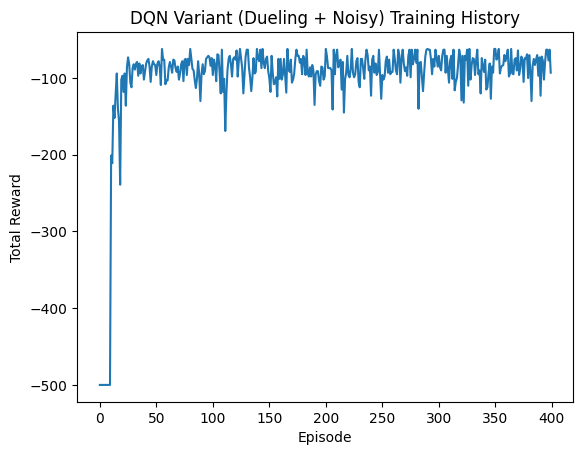

In [23]:
# TODO: Instantiate the agent and train it
agent = DQNVariant()
agent, reward_history = train_dqn_variant(agent, seed=42)

# TODO: Plot the reward history to see how the agent's performance changes over time
plt.plot(reward_history)
plt.xlabel("Episode")
plt.ylabel("Total Reward")
plt.title("DQN Variant (Dueling + Noisy) Training History")
plt.show()

### Discussion: Comparing the Performance of Two Agents (5%)  

Compare your improved DQN agent with the original in 150 words or less by addressing the following:

- What method(s) you used
- Why it improved performance
- Results comparison

TODO: Write down your answer here.

### Testing the Improved DQN Agent (10%)

You will receive full points only if both of the following conditions are met:

- The average reward is greater than -75
- The average reward is higher than your original DQN agent

**Do not modify the cell below, or you will get 0 points for this question.**

ALSA lib confmisc.c:855:(parse_card) [error.core] cannot find card '0'
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) [error.core] error evaluating strings
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1342:(snd_func_refer) [error.core] error evaluating name
ALSA lib conf.c:5207:(_snd_config_evaluate) [error.core] function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5730:(snd_config_expand) [error.core] Evaluate error: No such file or directory
ALSA lib pcm.c:2722:(snd_pcm_open_noupdate) [error.pcm] Unknown PCM default


Reward: -102.0
Reward: -71.0
Reward: -72.0
Reward: -87.0
Reward: -72.0
Reward: -92.0
Reward: -70.0
Reward: -92.0
Reward: -85.0
Reward: -71.0
Average reward: -81.4
Mean episode length: 82.4


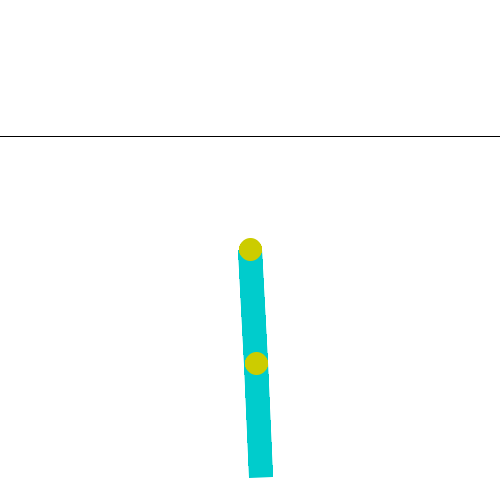

In [27]:
env_render = gym.make("Acrobot-v1", render_mode="rgb_array")
trained_policy = lambda state: agent.select_action(state, epsilon=0.0)
gif_filename = evaluate_policy(env_render, trained_policy, filename="DQN_variant_evaluation.gif")
env_render.close()
display(Image(filename=gif_filename))